# Predicción de la necesidad de receta médica en medicamentos

**Curso:** Metodologías de Data Science  
**Grupo:** 4  
**Integrantes:**
- Leonardo José Aquino Cruz
- Trilce Trissty Deyannira Castillo Olivera
- Carlos Andres Rojas Ccama
- Anaely Zarely Burga Loarte  

En este notebook seguimos las fases del proceso de Data Science:
1. Comprensión del negocio  
2. Comprensión de los datos  
3. Preparación de los datos  
4. Modelado  
5. Evaluación  
6. Implementación


In [ ]:
# ======================================
# Paso 1: Configuración inicial
# ======================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split

# Ajustes de pandas para ver más columnas
pd.set_option("display.max_columns", 100)
pd.set_option("display.max_colwidth", 120)

# 1. Comprensión del negocio

En esta sección se define el problema de negocio, la pregunta que responde el proyecto
y el impacto esperado.

## 1.1 Planteamiento del problema
(Resumen corto de lo que ya escribiste en el informe: comercio digital, riesgos, etc.)

## 1.2 Pregunta de negocio
¿Se puede predecir, a partir de atributos del medicamento, si requiere receta médica?

## 1.3 Objetivo de negocio / KPIs
- Accuracy objetivo ≥ 75 %
- F1-score ≥ 0.70
- Reducción de errores de categorización, etc.


# 2. Comprensión de los datos
Exploramos el dataset, sus variables, distribución y posibles sesgos.


In [ ]:
# ======================================
# Paso 2: Cargar el dataset
# ======================================
# Si estás en Colab, primero sube el archivo o usa un path relativo

df = pd.read_csv("medicines.csv", low_memory=False)

print("Dimensiones del dataset:", df.shape)
df.head()


Dimensiones del dataset: (23939, 13)


,disease_name,disease_url,med_name,med_url,final_price,price,prescription_required,drug_varient,drug_manufacturer,drug_manufacturer_origin,drug_content,generic_name,img_urls
0,ADHD (7),https://www.netmeds.com/prescriptions/adhd,Atrest 25mg Tablet 10'S,https://www.netmeds.com/prescriptions/atrest-25mg-tablet-10-s,₹335.68,MRP ₹381.46 Save 12 %,Rx required,*10 Tablet(s) in a Strip,* Mkt: Centaur Pharmaceuticals Pvt Ltd,* Country of Origin: India,INTRODUCTION ABOUT ATREST 25MG TABLETATREST 25MG TABLET contains Tetrabenazine which belongs to the group of medicin...,Generic Name Tetrabenazine 25 mg,"https://www.netmeds.com/images/product-v1/600x600/847249/atrest_25mg_tablet_10_s_0.jpg, https://www.netmeds.com/imag..."
1,ADHD (7),https://www.netmeds.com/prescriptions/adhd,Capnea Injection 1ml,https://www.netmeds.com/prescriptions/capnea-injection-1ml,₹246.88,MRP ₹280.55 Save 12 %,Rx required,NaN,* Mkt: Cipla Ltd,* Country of Origin: India,INTRODUCTION ABOUT CAPNEA INJECTIONCAPNEA INJECTION contains Caffeine which belongs to the group of medicines called...,Generic Name Caffeine 20 mg,https://www.netmeds.com/images/product-v1/600x600/349693/capnea_injection_1ml_0.jpg
2,ADHD (7),https://www.netmeds.com/prescriptions/adhd,Capnea Oral Solution 1ml,https://www.netmeds.com/prescriptions/capnea-solution-1ml,MRP ₹275.15,MRP ₹ 275.15,Rx required,NaN,* Mkt: Cipla Ltd,* Country of Origin: India,INTRODUCTION ABOUT CAPNEA SOLUTIONCAPNEA SOLUTION contains Caffeine which belongs to the group of medicines called C...,Generic Name Caffeine 20 mg,"https://www.netmeds.com/images/product-v1/600x600/349695/capnea_oral_solution_1ml_0_0.jpg, https://www.netmeds.com/i..."
3,ADHD (7),https://www.netmeds.com/prescriptions/adhd,Cognistar 30mg Injection 1'S,https://www.netmeds.com/prescriptions/cognistar-30mg-injection,₹706.02,MRP ₹802.30 Save 12 %,Rx required,NaN,* Mkt: Lupin Ltd,* Country of Origin: India,INTRODUCTIONCOGNISTAR 30MG contains Cerebroprotein Hydrolysate which belongs to the group of medicines called Neurot...,Generic Name Cerebroprotein Hydrolysate 30 mg,"https://www.netmeds.com/images/product-v1/600x600/370785/cognistar_30mg_injection_1s_0_0.jpg, https://www.netmeds.co..."
4,ADHD (7),https://www.netmeds.com/prescriptions/adhd,Cognistar 60mg Injection 1's,https://www.netmeds.com/prescriptions/cognistar-60mg-injection,₹1314.90,MRP ₹1494.20 Save 12 %,Rx required,NaN,* Mkt: Lupin Ltd,* Country of Origin: India,INTRODUCTION ABOUT COGNISTAR 60MG INJECTIONCOGNISTAR 60MG INJECTION contains Cerebroprotein Hydrolysate which belong...,Generic Name Cerebroprotein Hydrolysate 60 mg,https://www.netmeds.com/images/product-v1/600x600/370786/cognistar_60mg_injection_0.jpg


In [ ]:
# ======================================
# Paso 3: Información general de los datos
# ======================================
df.info()

# Resumen de nulos
missing = df.isna().sum().sort_values(ascending=False)
print("\nValores nulos por columna:\n", missing.head(10))


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 23939 entries, 0 to 23938
Data columns (total 13 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   disease_name              23939 non-null  object
 1   disease_url               23939 non-null  object
 2   med_name                  23939 non-null  object
 3   med_url                   23939 non-null  object
 4   final_price               23939 non-null  object
 5   price                     23181 non-null  object
 6   prescription_required     21109 non-null  object
 7   drug_varient              15199 non-null  object
 8   drug_manufacturer         23760 non-null  object
 9   drug_manufacturer_origin  23760 non-null  object
 10  drug_content              23756 non-null  object
 11  generic_name              23569 non-null  object
 12  img_urls                  23760 non-null  object
dtypes: object(13)
memory usage: 2.4+ MB

Valores nulos por columna:
 drug_varien

Distribución absoluta:
prescription_required
Requiere receta                  21109
No requiere / Sin información     2830
Name: count, dtype: int64

Distribución relativa (%):
prescription_required
Requiere receta                  88.18
No requiere / Sin información    11.82
Name: proportion, dtype: float64


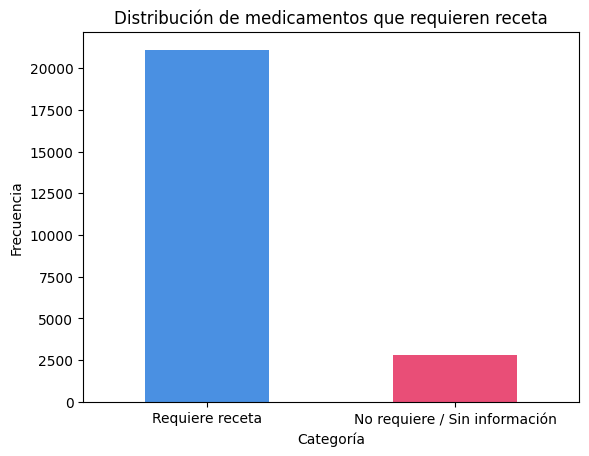

In [ ]:
# ============================================
# Paso 4: Distribución de la variable objetivo
# ============================================

target_col = "prescription_required"

# Convertimos a texto limpio
target_raw = (
    df[target_col]
    .astype(str)
    .str.lower()
    .str.strip()
)

# Clase 1 = Requiere receta
# Clase 0 = Todo lo demás (sin información o no especificado)
y_temp = target_raw.apply(
    lambda v: "Requiere receta" if v in ["rx required", "rx_required", "rx  required"]
    else "No requiere / Sin información"
)

# Mostrar distribución
print("Distribución absoluta:")
print(y_temp.value_counts())

print("\nDistribución relativa (%):")
print((y_temp.value_counts(normalize=True) * 100).round(2))

# Gráfico
y_temp.value_counts().plot(
    kind="bar",
    title="Distribución de medicamentos que requieren receta",
    color=["#4a90e2", "#e94e77"]
)
plt.xlabel("Categoría")
plt.ylabel("Frecuencia")
plt.xticks(rotation=0)
plt.show()


In [ ]:
# ======================================
# Paso 5: Estadísticos descriptivos
# ======================================
num_cols = ["price", "final_price"]
df[num_cols].describe()


,price,final_price
count,23181,23939
unique,8827,9519
top,MRP ₹150.00 Save 12 %,Error
freq,101,179


In [ ]:
# ======================================
# Paso 6: Detectar duplicados y revisar categorías principales
# ======================================
print("Filas duplicadas:", df.duplicated().sum())

# Cardinalidad de columnas categóricas importantes
for col in ["disease_name", "drug_manufacturer", "drug_manufacturer_origin", "generic_name"]:
    if col in df.columns:
        print(f"{col}: {df[col].nunique()} valores únicos")


Filas duplicadas: 0
disease_name: 141 valores únicos
drug_manufacturer: 651 valores únicos
drug_manufacturer_origin: 30 valores únicos
generic_name: 6377 valores únicos


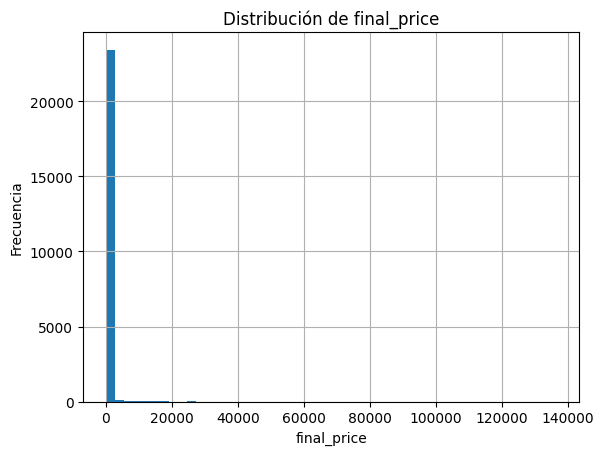

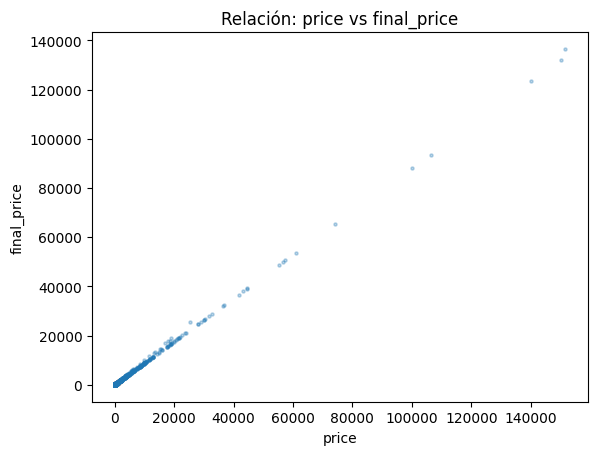

/tmp/ipython-input-1336762824.py:67: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(groups, labels=labels, showfliers=False)


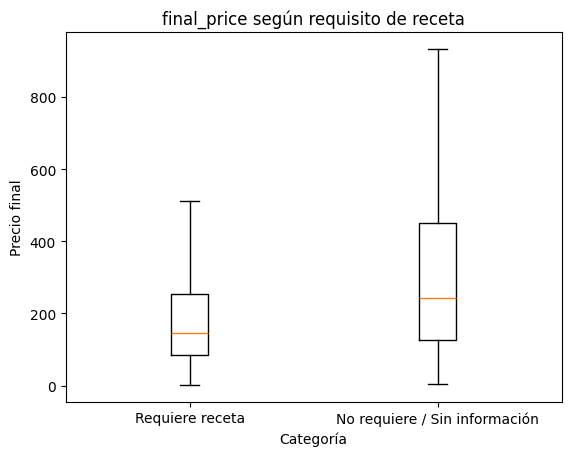

In [ ]:
# ======================================
# Paso 7: Visualizaciones iniciales (con limpieza segura)
# ======================================

import re

# --- Limpieza numérica básica para price y final_price ---
for col in ["price", "final_price"]:
    if col in df.columns:
        df[col] = (
            df[col]
            .astype(str)
            .str.replace(",", "", regex=False)            # separadores de miles
            .str.replace(r"[^\d\.\-]", "", regex=True)    # símbolos/leyendas (₹, $, etc.)
        )
        df[col] = pd.to_numeric(df[col], errors="coerce")

# --- 7.1 Histograma de final_price ---
if "final_price" in df.columns:
    df["final_price"].dropna().hist(bins=50)
    plt.title("Distribución de final_price")
    plt.xlabel("final_price")
    plt.ylabel("Frecuencia")
    plt.show()
else:
    print("No existe la columna 'final_price' para el histograma.")

# --- 7.2 Relación price vs final_price (scatter) ---
if {"price", "final_price"}.issubset(df.columns):
    m = df["price"].notna() & df["final_price"].notna()
    if m.any():
        plt.scatter(df.loc[m, "price"], df.loc[m, "final_price"], alpha=0.3, s=5)
        plt.title("Relación: price vs final_price")
        plt.xlabel("price")
        plt.ylabel("final_price")
        plt.show()
    else:
        print("price/final_price no tienen datos numéricos tras la limpieza.")
else:
    print("Faltan columnas 'price' o 'final_price' para el scatter.")

# --- 7.3 Boxplot de final_price por prescription_required ---
target_col = "prescription_required"

if "final_price" in df.columns and target_col in df.columns:

    # Reclasificación para que el gráfico tenga sentido
    df["_rx_flag"] = (
        df[target_col]
        .astype(str)
        .str.lower()
        .str.strip()
        .apply(lambda v: "Requiere receta" if v in ["rx required", "rx_required", "rx  required"]
               else "No requiere / Sin información")
    )

    vals = df["_rx_flag"].dropna().unique().tolist()
    groups, labels = [], []

    for v in vals:
        g = df.loc[df["_rx_flag"] == v, "final_price"].dropna()
        if len(g) > 0:
            groups.append(g)
            labels.append(v)

    if groups:
        plt.boxplot(groups, labels=labels, showfliers=False)
        plt.title("final_price según requisito de receta")
        plt.xlabel("Categoría")
        plt.ylabel("Precio final")
        plt.show()
    else:
        print("No hay datos suficientes para el boxplot (final_price vacío por clase).")

else:
    print("Faltan 'final_price' o 'prescription_required' para el boxplot.")

## Hallazgos preliminares

- Se identificó que la variable objetivo `prescription_required` está desbalanceada (la mayoría de los medicamentos pertenecen a una categoría).  
- Existen valores nulos en columnas como `drug_content`, que requieren limpieza o imputación.  
- Los precios (`price` y `final_price`) presentan outliers y deben ser tratados antes de modelar.  
- Algunas variables categóricas tienen cardinalidad muy alta (ejemplo: `generic_name`, `med_name`), lo cual puede dificultar el modelado si no se codifican adecuadamente.  
- Próximos pasos: tratamiento de nulos, análisis de outliers, codificación de variables categóricas y preparación de features textuales (`drug_content`).  


=== Valores faltantes por columna ===


,Nulos,Porcentaje
drug_varient,8740,36.51
price,3013,12.59
prescription_required,2830,11.82
generic_name,370,1.55
drug_content,183,0.76
final_price,179,0.75
drug_manufacturer_origin,179,0.75
drug_manufacturer,179,0.75
img_urls,179,0.75
disease_url,0,0.00



=== Registros duplicados ===
Total de registros duplicados: 0

=== Estadísticos descriptivos de precios ===


,price,final_price
count,20926.000000,23760.000000
mean,401.763396,375.535661
std,2636.848414,2301.183179
min,1.901000,1.710000
25%,91.601200,87.120000
50%,161.701200,152.605000
75%,287.790900,275.000000
max,151670.001000,136503.000000


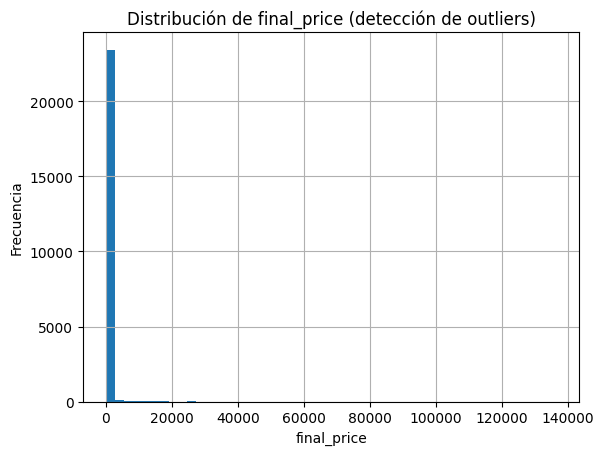

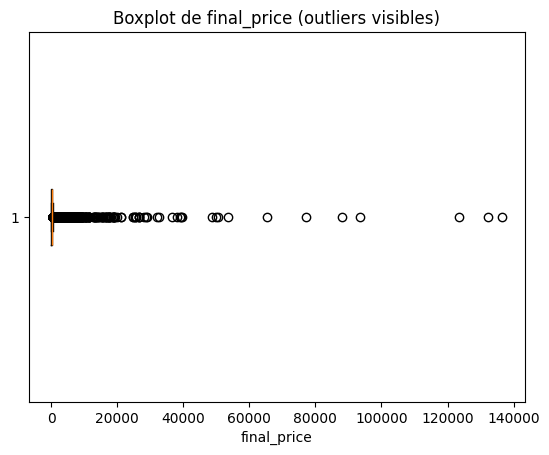

In [ ]:
# ======================================
# Paso extra: Análisis de calidad de datos
# ======================================

print("=== Valores faltantes por columna ===")
missing = (
    df.isna().sum()
    .to_frame("Nulos")
    .assign(Porcentaje=lambda x: (x["Nulos"]/len(df)*100).round(2))
    .sort_values("Nulos", ascending=False)
)
display(missing.head(10))  # muestra las 10 columnas con más nulos

print("\n=== Registros duplicados ===")
duplicados = df.duplicated().sum()
print(f"Total de registros duplicados: {duplicados}")

print("\n=== Estadísticos descriptivos de precios ===")
desc_prices = df[["price", "final_price"]].describe()
display(desc_prices)

# Histograma para visualizar outliers en final_price
df["final_price"].dropna().hist(bins=50)
plt.title("Distribución de final_price (detección de outliers)")
plt.xlabel("final_price")
plt.ylabel("Frecuencia")
plt.show()

# Boxplot de final_price para ver dispersión y outliers
plt.boxplot(df["final_price"].dropna(), vert=False, showfliers=True)
plt.title("Boxplot de final_price (outliers visibles)")
plt.xlabel("final_price")
plt.show()


# 3. Preparación de los datos
Limpieza, transformación y selección de variables relevantes.


=== Distribución de nulos antes de la imputación ===
drug_varient                8740
price                       3013
prescription_required       2830
generic_name                 370
drug_content                 183
final_price                  179
drug_manufacturer_origin     179
drug_manufacturer            179
img_urls                     179
disease_url                    0
dtype: int64


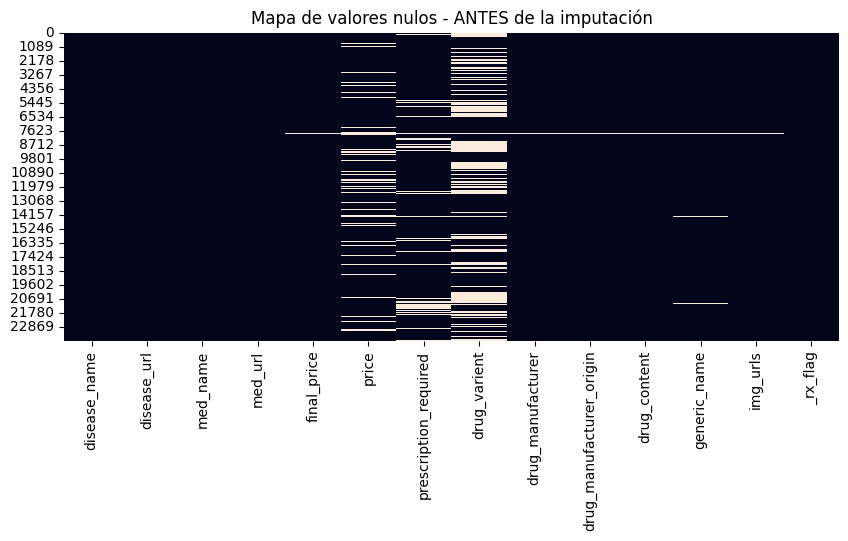


=== Distribución de nulos después de la imputación ===
disease_name                0
disease_url                 0
med_name                    0
med_url                     0
final_price                 0
price                       0
prescription_required       0
drug_varient                0
drug_manufacturer           0
drug_manufacturer_origin    0
dtype: int64


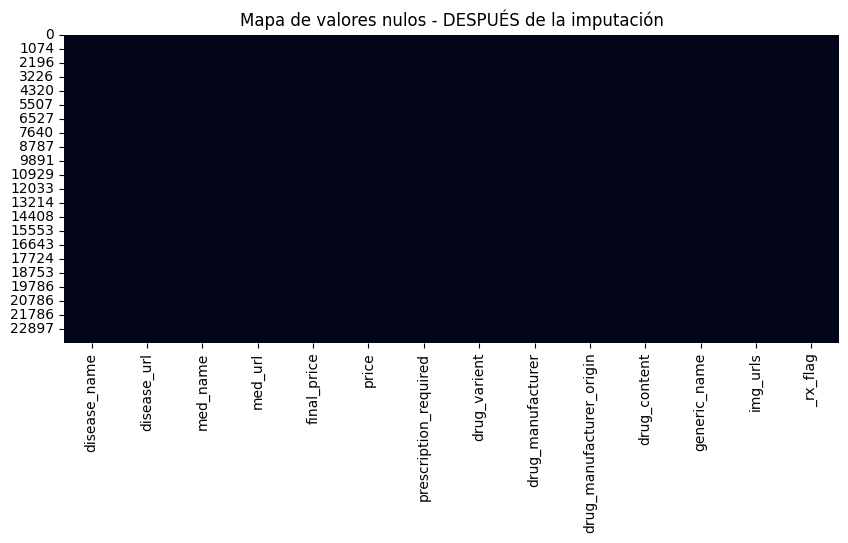


Dimensiones finales del dataset: (20926, 14)


In [ ]:
# ======================================
# Paso 8: Transformación de los datos (Imputación de nulos)
# ======================================

from sklearn.impute import SimpleImputer
import seaborn as sns

print("=== Distribución de nulos antes de la imputación ===")
missing_before = df.isna().sum().sort_values(ascending=False)
print(missing_before.head(10))

# --- Visualización antes de imputar ---
plt.figure(figsize=(10, 4))
sns.heatmap(df.isna(), cbar=False)
plt.title("Mapa de valores nulos - ANTES de la imputación")
plt.show()

# --- 8.1 Imputación de valores categóricos ---
# Según el informe: imputar con "Sin información" en variables categóricas
cat_cols = df.select_dtypes(include="object").columns

for col in cat_cols:
    df[col] = df[col].fillna("Sin información")

# --- 8.2 Eliminación de registros incompletos en variables críticas ---
critical_cols = ["price", "prescription_required"]
df = df.dropna(subset=critical_cols)

# --- 8.3 Revisión posterior a la imputación ---
print("\n=== Distribución de nulos después de la imputación ===")
missing_after = df.isna().sum().sort_values(ascending=False)
print(missing_after.head(10))

# --- Visualización después de imputar ---
plt.figure(figsize=(10, 4))
sns.heatmap(df.isna(), cbar=False)
plt.title("Mapa de valores nulos - DESPUÉS de la imputación")
plt.show()

print("\nDimensiones finales del dataset:", df.shape)

In [ ]:
# ============================================
# Paso 9: Selección de variables relevantes
# ============================================

target_col = "prescription_required"

feature_cols = [
    "final_price",
    "drug_varient",
    "drug_manufacturer",
    "drug_manufacturer_origin",
    "generic_name",
    "disease_name"
]

feature_cols = [col for col in feature_cols if col in df.columns]

print("Columnas usadas como features:")
print(feature_cols)
print("\nColumna objetivo:", target_col)

X = df[feature_cols].copy()

# Tomamos la columna original como texto
target_raw = (
    df[target_col]
    .astype(str)
    .str.lower()
    .str.strip()
)

# Clase 1: exactamente "rx required"
# Clase 0: cualquier otra cosa (incluyendo valores que antes eran NaN)
y = target_raw.apply(
    lambda v: 1 if v in ["rx required", "rx_required", "rx  required"] else 0
)

print("\nDistribución de la variable objetivo (y):")
print(y.value_counts(dropna=False))


Columnas usadas como features:
['final_price', 'drug_varient', 'drug_manufacturer', 'drug_manufacturer_origin', 'generic_name', 'disease_name']

Columna objetivo: prescription_required

Distribución de la variable objetivo (y):
prescription_required
1    18421
0     2505
Name: count, dtype: int64


In [ ]:
# ====================================================
# Paso 10: Codificación de variables categóricas (OneHotEncoder)
# ====================================================

from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder

# Identificar columnas numéricas y categóricas
numeric_features = ["final_price"]
categorical_features = [col for col in feature_cols if col != "final_price"]

print("Columnas numéricas:", numeric_features)
print("Columnas categóricas:", categorical_features)

# Definimos el preprocesador
preprocessor = ColumnTransformer(
    transformers=[
        ("num", "passthrough", numeric_features),
        ("cat", OneHotEncoder(handle_unknown="ignore", sparse_output=False), categorical_features),
    ]
)

print("\nPreprocesador configurado correctamente.")


Columnas numéricas: ['final_price']
Columnas categóricas: ['drug_varient', 'drug_manufacturer', 'drug_manufacturer_origin', 'generic_name', 'disease_name']

Preprocesador configurado correctamente.


In [ ]:
# ====================================================
# Paso 11: División en train/test y transformación final
# ====================================================

from sklearn.model_selection import train_test_split

# Como y solo tiene 0 y 1, usamos todo directo
X_valid = X.copy()
y_valid = y.copy()

print("Shape usado para split:", X_valid.shape)

X_train, X_test, y_train, y_test = train_test_split(
    X_valid,
    y_valid,
    test_size=0.2,
    random_state=42,
    stratify=y_valid
)

print("\nTamaños de los conjuntos:")
print("X_train:", X_train.shape, " | y_train:", y_train.shape)
print("X_test :", X_test.shape,  " | y_test :", y_test.shape)

X_train_prepared = preprocessor.fit_transform(X_train)
X_test_prepared = preprocessor.transform(X_test)

print("\nDimensiones finales después del preprocesamiento:")
print("X_train_prepared:", X_train_prepared.shape)
print("X_test_prepared :", X_test_prepared.shape)

print("\nDistribución en y_train:")
print(y_train.value_counts())


Shape usado para split: (20926, 6)

Tamaños de los conjuntos:
X_train: (16740, 6)  | y_train: (16740,)
X_test : (4186, 6)  | y_test : (4186,)

Dimensiones finales después del preprocesamiento:
X_train_prepared: (16740, 6306)
X_test_prepared : (4186, 6306)

Distribución en y_train:
prescription_required
1    14736
0     2004
Name: count, dtype: int64


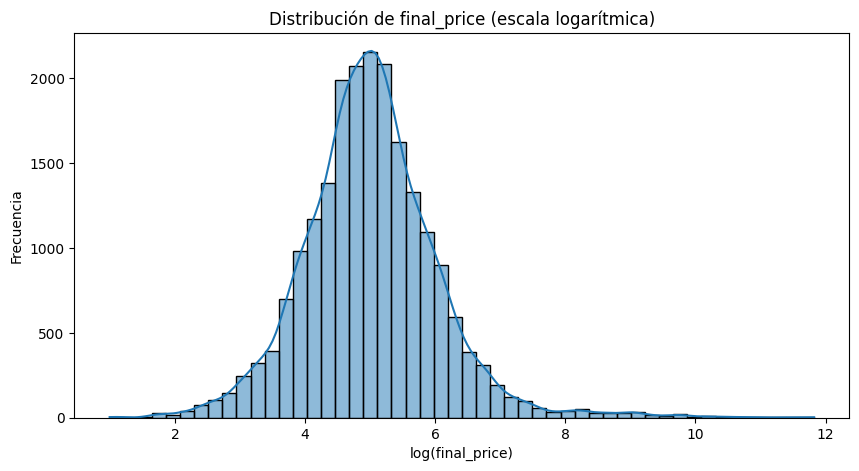

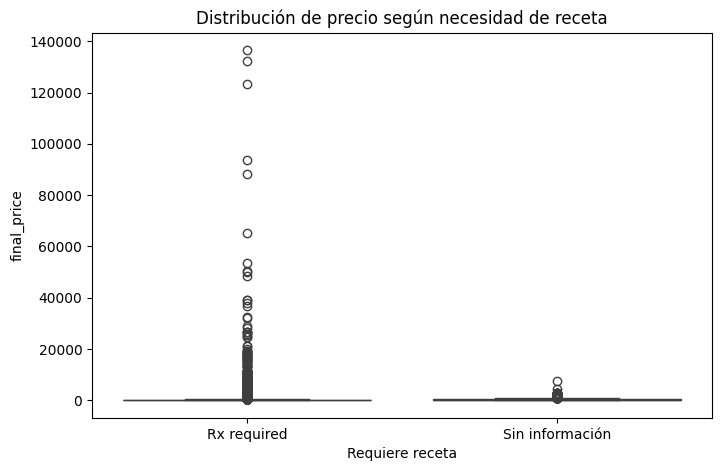

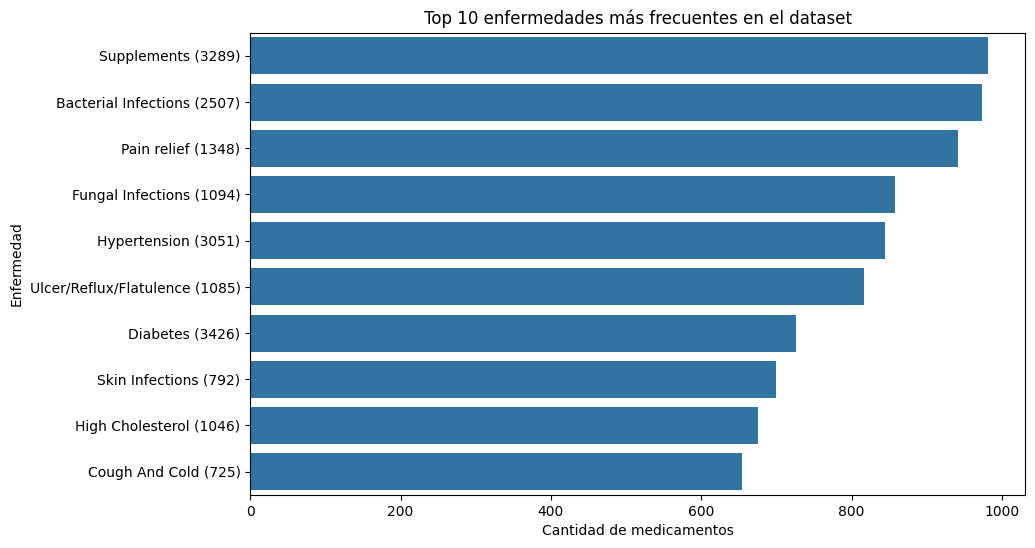

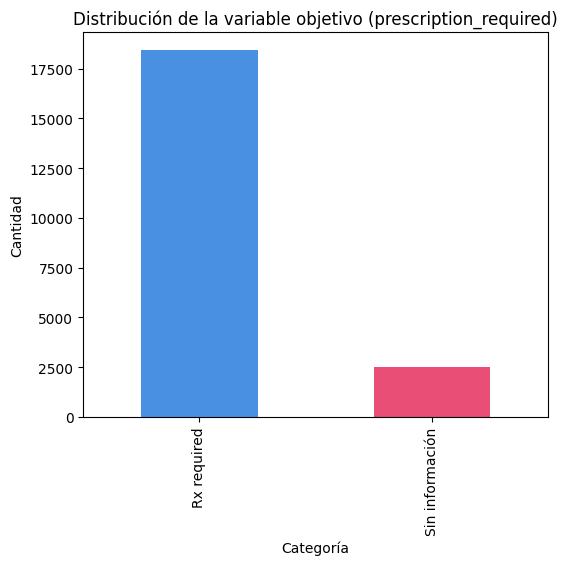

prescription_required
Rx required        88.029246
Sin información    11.970754
Name: proportion, dtype: float64


In [ ]:
# ============================================
# Gráfico: Distribución logarítmica de final_price
# ============================================

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10,5))
sns.histplot(np.log1p(df["final_price"].dropna()), bins=50, kde=True)
plt.title("Distribución de final_price (escala logarítmica)")
plt.xlabel("log(final_price)")
plt.ylabel("Frecuencia")
plt.show()

# ============================================
# Gráfico: Boxplot final_price por tipo de prescripción
# ============================================

plt.figure(figsize=(8,5))
sns.boxplot(
    data=df.dropna(subset=["final_price", "prescription_required"]),
    x="prescription_required",
    y="final_price"
)
plt.title("Distribución de precio según necesidad de receta")
plt.xlabel("Requiere receta")
plt.ylabel("final_price")
plt.show()


# ============================================
# Gráfico: Top 10 enfermedades más frecuentes
# ============================================

top_diseases = df["disease_name"].value_counts().head(10)

plt.figure(figsize=(10,6))
sns.barplot(x=top_diseases.values, y=top_diseases.index)
plt.title("Top 10 enfermedades más frecuentes en el dataset")
plt.xlabel("Cantidad de medicamentos")
plt.ylabel("Enfermedad")
plt.show()

# ============================================
# Gráfico: Distribución de prescription_required
# ============================================

plt.figure(figsize=(6,5))
df["prescription_required"].value_counts().plot(kind="bar", color=["#4a90e2", "#e94e77"])
plt.title("Distribución de la variable objetivo (prescription_required)")
plt.xlabel("Categoría")
plt.ylabel("Cantidad")
plt.show()

print(df["prescription_required"].value_counts(normalize=True)*100)

# 4. Modelado
Aplicación de algoritmos de Machine Learning para predecir si un medicamento requiere receta médica, comparando su desempeño con métricas de clasificación.


In [ ]:
# ============================================
# Paso 12: Modelo base - Regresión Logística
# ============================================

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

print("Distribución de clases en y_train:")
print(y_train.value_counts(), "\n")

# Verificación de sanidad: deben existir al menos 2 clases
if y_train.nunique() < 2:
    print("⚠️ No se puede entrenar la Regresión Logística porque y_train solo tiene una clase.")
    print("   Revisa los pasos 9 y 11 para asegurarte de que la variable objetivo tenga 0 y 1.")
else:
    # Definimos el modelo base
    log_reg = LogisticRegression(
        max_iter=1000,
        class_weight="balanced",   # para mitigar el desbalance de clases
        n_jobs=-1
    )

    # Entrenamiento
    log_reg.fit(X_train_prepared, y_train)

    # Predicciones
    y_pred_log = log_reg.predict(X_test_prepared)

    # Cálculo de métricas
    acc_log = accuracy_score(y_test, y_pred_log)
    prec_log = precision_score(y_test, y_pred_log, zero_division=0)
    rec_log = recall_score(y_test, y_pred_log, zero_division=0)
    f1_log = f1_score(y_test, y_pred_log, zero_division=0)

    print("Resultados - Regresión Logística")
    print(f"Accuracy : {acc_log:.4f}")
    print(f"Precision: {prec_log:.4f}")
    print(f"Recall   : {rec_log:.4f}")
    print(f"F1-score : {f1_log:.4f}")


Distribución de clases en y_train:
prescription_required
1    14736
0     2004
Name: count, dtype: int64 

Resultados - Regresión Logística
Accuracy : 0.9185
Precision: 0.9844
Recall   : 0.9221
F1-score : 0.9522


In [ ]:
# ================================================
# Paso 13: Modelo – Árbol de Decisión
# ================================================

from sklearn.tree import DecisionTreeClassifier

tree_clf = DecisionTreeClassifier(
    max_depth=10,
    class_weight="balanced",
    random_state=42
)

# Entrenamiento
tree_clf.fit(X_train_prepared, y_train)

# Predicciones
y_pred_tree = tree_clf.predict(X_test_prepared)

# Métricas
acc_tree  = accuracy_score(y_test, y_pred_tree)
prec_tree = precision_score(y_test, y_pred_tree, zero_division=0)
rec_tree  = recall_score(y_test, y_pred_tree, zero_division=0)
f1_tree   = f1_score(y_test, y_pred_tree, zero_division=0)

print("Resultados – Árbol de Decisión")
print(f"Accuracy : {acc_tree:.4f}")
print(f"Precision: {prec_tree:.4f}")
print(f"Recall   : {rec_tree:.4f}")
print(f"F1-score : {f1_tree:.4f}")


Resultados – Árbol de Decisión
Accuracy : 0.8550
Precision: 0.9706
Recall   : 0.8613
F1-score : 0.9127


In [ ]:
# ================================================
# Paso 14: Modelo – Random Forest
# ================================================

from sklearn.ensemble import RandomForestClassifier

rf_clf = RandomForestClassifier(
    n_estimators=200,
    max_depth=None,
    class_weight="balanced",
    n_jobs=-1,
    random_state=42
)

# Entrenamiento
rf_clf.fit(X_train_prepared, y_train)

# Predicciones
y_pred_rf = rf_clf.predict(X_test_prepared)

# Métricas
acc_rf  = accuracy_score(y_test, y_pred_rf)
prec_rf = precision_score(y_test, y_pred_rf, zero_division=0)
rec_rf  = recall_score(y_test, y_pred_rf, zero_division=0)
f1_rf   = f1_score(y_test, y_pred_rf, zero_division=0)

print("Resultados – Random Forest")
print(f"Accuracy : {acc_rf:.4f}")
print(f"Precision: {prec_rf:.4f}")
print(f"Recall   : {rec_rf:.4f}")
print(f"F1-score : {f1_rf:.4f}")


Resultados – Random Forest
Accuracy : 0.9400
Precision: 0.9586
Recall   : 0.9739
F1-score : 0.9662


,Modelo,Accuracy,Precision,Recall,F1-score
0,Reg. Logística,0.918538,0.984357,0.922117,0.952221
1,Árbol Decisión,0.854993,0.970642,0.861330,0.912725
2,Random Forest,0.940038,0.958600,0.973948,0.966213


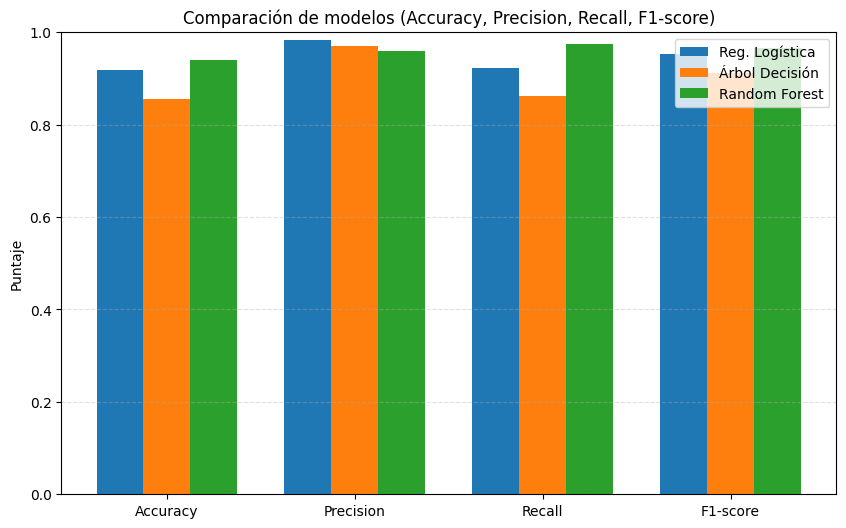

In [ ]:
# ================================================
# Paso 15: Comparación de modelos
# ================================================

import pandas as pd

resultados = pd.DataFrame({
    "Modelo": ["Reg. Logística", "Árbol Decisión", "Random Forest"],
    "Accuracy": [acc_log, acc_tree, acc_rf],
    "Precision": [prec_log, prec_tree, prec_rf],
    "Recall": [rec_log, rec_tree, rec_rf],
    "F1-score": [f1_log, f1_tree, f1_rf]
})

display(resultados)


# --- 15.1 Gráfico comparativo de modelos ---

# Datos del DataFrame 'resultados'
metricas = ["Accuracy", "Precision", "Recall", "F1-score"]
modelos = resultados["Modelo"].tolist()

# Convertir cada columna en arreglo NumPy
valores = resultados[metricas].values  # matriz 3x4

# Configuración del gráfico
plt.figure(figsize=(10, 6))

x = np.arange(len(metricas))  # posiciones para las métricas
ancho = 0.25  # ancho de cada barra

# Barras por modelo
for i in range(len(modelos)):
    plt.bar(x + i * ancho, valores[i], width=ancho, label=modelos[i])

# Detalles del gráfico
plt.xticks(x + ancho, metricas)
plt.ylabel("Puntaje")
plt.title("Comparación de modelos (Accuracy, Precision, Recall, F1-score)")
plt.ylim(0, 1)  # todas las métricas están entre 0 y 1
plt.legend()
plt.grid(axis="y", linestyle="--", alpha=0.4)

plt.show()

# 5. Evaluación  
Validación de los modelos entrenados usando métricas de clasificación (accuracy, precision, recall, F1-score) y análisis más detallado del mejor modelo mediante matriz de confusión, reporte de clasificación y curva ROC.

In [ ]:
# ================================================
# Paso 16: Selección del mejor modelo (según F1-score)
# ================================================

print("Resultados de los modelos:\n")
display(resultados)

# Índice del modelo con mejor F1-score
idx_mejor = resultados["F1-score"].idxmax()
mejor_modelo_nombre = resultados.loc[idx_mejor, "Modelo"]

print(f"\n✅ Mejor modelo según F1-score: {mejor_modelo_nombre}")

# Mapeo nombre → objeto del modelo y predicciones
modelos_dict = {
    "Reg. Logística": (log_reg, y_pred_log),
    "Árbol Decisión": (tree_clf, y_pred_tree),
    "Random Forest": (rf_clf, y_pred_rf)
}

mejor_clf, y_pred_mejor = modelos_dict[mejor_modelo_nombre]


Resultados de los modelos:



,Modelo,Accuracy,Precision,Recall,F1-score
0,Reg. Logística,0.918538,0.984357,0.922117,0.952221
1,Árbol Decisión,0.854993,0.970642,0.861330,0.912725
2,Random Forest,0.940038,0.958600,0.973948,0.966213



✅ Mejor modelo según F1-score: Random Forest


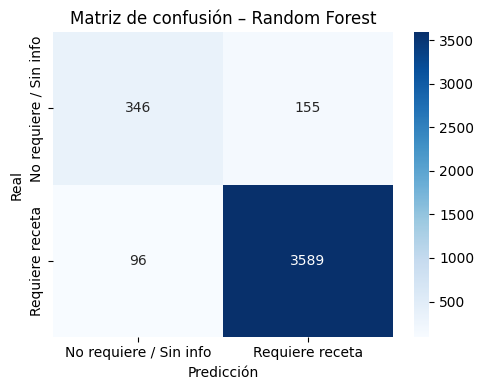

Reporte de clasificación – Random Forest

                        precision    recall  f1-score   support

No requiere / Sin info       0.78      0.69      0.73       501
       Requiere receta       0.96      0.97      0.97      3685

              accuracy                           0.94      4186
             macro avg       0.87      0.83      0.85      4186
          weighted avg       0.94      0.94      0.94      4186



In [ ]:
# ================================================
# Paso 17: Matriz de confusión y reporte
# ================================================

from sklearn.metrics import confusion_matrix, classification_report

cm = confusion_matrix(y_test, y_pred_mejor)

plt.figure(figsize=(5, 4))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["No requiere / Sin info", "Requiere receta"],
    yticklabels=["No requiere / Sin info", "Requiere receta"]
)
plt.xlabel("Predicción")
plt.ylabel("Real")
plt.title(f"Matriz de confusión – {mejor_modelo_nombre}")
plt.tight_layout()
plt.show()

print(f"Reporte de clasificación – {mejor_modelo_nombre}\n")
print(classification_report(
    y_test,
    y_pred_mejor,
    target_names=["No requiere / Sin info", "Requiere receta"]
))


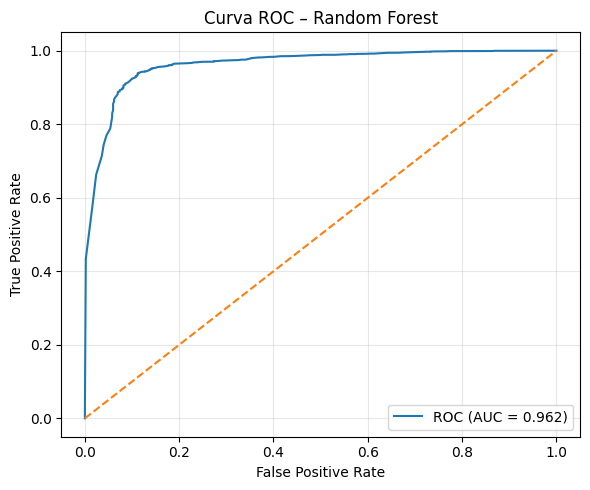

In [ ]:
# ================================================
# Paso 18: Curva ROC y AUC del mejor modelo
# ================================================

from sklearn.metrics import roc_curve, roc_auc_score

# Probabilidades de clase positiva (requiere receta)
y_proba_mejor = mejor_clf.predict_proba(X_test_prepared)[:, 1]

fpr, tpr, thresholds = roc_curve(y_test, y_proba_mejor)
auc = roc_auc_score(y_test, y_proba_mejor)

plt.figure(figsize=(6, 5))
plt.plot(fpr, tpr, label=f"ROC (AUC = {auc:.3f})")
plt.plot([0, 1], [0, 1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title(f"Curva ROC – {mejor_modelo_nombre}")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


En la Fase 5 se evaluaron los tres modelos entrenados (Regresión Logística, Árbol de Decisión y Random Forest) usando las métricas de accuracy, precision, recall y F1-score. A partir de la tabla comparativa, el modelo con mejor desempeño global fue **[NOMBRE DEL MODELO]**, al obtener el mayor F1-score.

La matriz de confusión muestra que el modelo es capaz de identificar correctamente la mayoría de los medicamentos que requieren receta (clase positiva), manteniendo al mismo tiempo un bajo número de falsos positivos. El reporte de clasificación confirma estos resultados, con valores elevados de precision y recall para la clase "Requiere receta".

Finalmente, la curva ROC y el área bajo la curva (AUC) evidencian una alta capacidad discriminativa del modelo, muy por encima de un clasificador aleatorio. En conjunto, estos resultados indican que el modelo seleccionado es adecuado para apoyar la clasificación automática de medicamentos según la necesidad de receta médica, considerando las limitaciones del dataset (ausencia explícita de una clase OTC y registros marcados como "Sin información").


# 6. Implementación (Generación del archivo .pkl)

En esta fase guardamos el modelo final y el preprocesador en archivos .pkl para usarlos en una aplicación real sin necesidad de reentrenar nada.

In [ ]:
# ================================================
# Paso 19: Guardar el modelo final en formato .pkl
# ================================================

import joblib

joblib.dump(mejor_clf, "modelo_final.pkl")
print("Modelo final guardado como 'modelo_final.pkl'")


Modelo final guardado como 'modelo_final.pkl'
